In [ ]:
# 03_ml_training.ipynb
# Goal of this notebook:
# - Take your (possibly harmonized) radiomics feature table
# - Attach center labels (e.g. center 1 vs center 2)
# - Split data into train / validation / test
# - Train three baseline models:
#     1) Logistic Regression
#     2) Random Forest
#     3) Gradient Boosting (XGBoost-style)
# - Save trained models and a test set snapshot for later evaluation
#
# You should:
# - Understand what X (features) and y (center labels) are
# - Understand what train/val/test splits are used for
# - Be able to inspect validation performance and decide which model is promising

***

## 0. Setup and imports

In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score

import pickle

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 0.1 Set project root and move there
PROJECTROOT = Path.cwd()
os.chdir(PROJECTROOT)

RAWROOT = PROJECTROOT / "data" / "raw"
PROCROOT = PROJECTROOT / "data" / "processed"
RESULTS = PROJECTROOT / "results"
MODELDIR = RESULTS / "models"
MODELDIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", os.getcwd())
print("Model directory:", MODELDIR)

Working directory: C:\Users\gijsk\Documents\Anaconda\AIIP-radiomics-project
Model directory: C:\Users\gijsk\Documents\Anaconda\AIIP-radiomics-project\results\models


In [9]:
import numpy as np
import pandas as pd

# Bestandspaden (ervan uitgaande dat RESULTS al is gedefinieerd in je notebook)
npy_path = RESULTS / "top20_features.npy"
csv_path = RESULTS / "top20_features.csv"

# 1. Laad de numpy array
features_array = np.load(npy_path, allow_pickle=True)

# 2. Maak er een tabel van met de kolomnaam die je originele code verwacht
df_features = pd.DataFrame(features_array, columns=["feature_name"])

# 3. Sla op als CSV (zonder de index-getallen als extra kolom op te slaan)
df_features.to_csv(csv_path, index=False)

print("✅ Succesvol omgezet! Je kunt nu je originele code runnen.")

✅ Succesvol omgezet! Je kunt nu je originele code runnen.


**Student direction:**

- Confirm paths match your environment (especially if running in a different folder).

***

## 1. Load features and center labels

We now load:

- Radiomics features (raw or harmonized).
- A list of selected feature names (e.g. top 20).
- Center labels (from `centerids.csv`).

In [10]:
from sklearn.model_selection import train_test_split

# 1.1 Choose which feature file to use:
#   - "features_raw.csv" (no harmonization)
#   - OR "features_harmonized.csv" (after ComBat from notebook 02)
FEATURE_FILE = PROCROOT / "features_raw.csv"  # change if you want harmonized

features_df = pd.read_csv(FEATURE_FILE)

# 1.2 Load center labels (caseid, centerid)
CENTER_FILE = RAWROOT / "centerids.csv"   # ensure this file exists
center_df = pd.read_csv(CENTER_FILE)

print("Features shape:", features_df.shape)
print("Center labels shape:", center_df.shape)
print("Center_df columns:", center_df.columns.tolist())

# 1.3 Load list of feature names to train on (e.g. top 20 stable features)
TOP_FEATURE_FILE = RESULTS / "top20_features.csv"   # adjust if needed
topfeat_df = pd.read_csv(TOP_FEATURE_FILE)
feature_names = topfeat_df["feature_name"].tolist()

print("Number of selected features:", len(feature_names))
print("First 5:", feature_names[:5])

# 1.4 Identify ID column name in features_df
print("Features columns:", features_df.columns.tolist())
ID_COL = "caseid"  # CHANGE if your column is "case_id" or similar

Features shape: (247, 103)
Center labels shape: (400, 2)
Center_df columns: ['case_id', 'center_id']
Number of selected features: 20
First 5: ['original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn']
Features columns: ['caseid', 'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firsto

**Student direction:**

- Make sure `ID_COL` matches your features table.
- Ensure `feature_names` are actually present in `features_df.columns`.

***

## 2. Build X (features) and y (labels), and check class balance

We merge features with center labels and build numpy arrays.

In [11]:
# 2.1 Merge features and center labels on ID
merged = features_df[[ID_COL] + feature_names].merge(
    center_df,
    left_on=ID_COL,
    right_on="case_id",   # or "case_id" depending on your file
    how="left",
)

# 2.2 Drop rows without known center
merged = merged.dropna(subset=["center_id"])

print("Merged shape:", merged.shape)
print("Columns:", merged.columns.tolist())

# 2.3 Build X and y
X_raw = merged[feature_names].to_numpy()
case_ids = merged[ID_COL].to_numpy()
y_raw = merged["center_id"].to_numpy()

# 2.4 Map center IDs to binary labels:
#     Suppose center 1 is coded as 1.0, center 2 as 2.0
#     We will map 1.0 -> 0 and 2.0 -> 1 for binary classification
y_aligned = np.where(y_raw == 2.0, 1, 0)

print("X_raw shape:", X_raw.shape)
print("Number of case_ids:", len(case_ids))
print("y_aligned shape:", y_aligned.shape)
print("Class counts:", pd.Series(y_aligned).value_counts().to_dict())

Merged shape: (247, 23)
Columns: ['caseid', 'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'case_id', 'center_id']
X_raw shape: (247, 20)
Number of case_ids: 247
y_aligned shape: (247,)
Class counts: {0: 195, 1: 52}


**Student direction:**

- Confirm that your data really has just two classes (0 and 1).
- If more centers exist, you’ll need to adapt labels or restrict to two of them.

***

## 3. Train / validation / test split

We split the data into three parts:

- Train: used to fit model parameters.
- Validation: used to tune hyperparameters and choose models.
- Test: held out until the very end.

In [12]:
n_samples = X_raw.shape[0]
indices = np.arange(n_samples)

test_size = 0.25  # 25% of data
val_size = 0.25   # 25% of data (from remaining)

# 3.1 First split: train vs temp (stratified on y for balanced classes)
# PSEUDOCODE:
X_train_idx, X_temp_idx, y_train, y_temp = train_test_split(
    indices,
    y_aligned,
    test_size=(val_size + test_size),
    random_state=42,
    stratify=y_aligned,
)

# 3.2 Second split: val vs test from temp (no stratify to avoid rare-class issues)
# PSEUDOCODE:
X_val_idx, X_test_idx, y_val, y_test = train_test_split(
    X_temp_idx,
    y_temp,
    test_size=test_size / (val_size + test_size),
    random_state=42,
    shuffle=True,
    stratify=None,
)

# 3.3 Print some diagnostics (pseudo-code)
print("\nTrain‑Val‑Test Split:")
print(f" Train: {len(X_train_idx)} samples ({len(X_train_idx)/len(y_aligned)*100:.1f}%)")
print(f" Val:   {len(X_val_idx)} samples ({len(X_val_idx)/len(y_aligned)*100:.1f}%)")
print(f" Test:  {len(X_test_idx)} samples ({len(X_test_idx)/len(y_aligned)*100:.1f}%)")
print("\nClass counts:")
print(" Train:\n", pd.Series(y_aligned[X_train_idx]).value_counts())
print(" Val:\n", pd.Series(y_aligned[X_val_idx]).value_counts())
print(" Test:\n", pd.Series(y_aligned[X_test_idx]).value_counts())


Train‑Val‑Test Split:
 Train: 123 samples (49.8%)
 Val:   62 samples (25.1%)
 Test:  62 samples (25.1%)

Class counts:
 Train:
 0    97
1    26
Name: count, dtype: int64
 Val:
 0    49
1    13
Name: count, dtype: int64
 Test:
 0    49
1    13
Name: count, dtype: int64


**Student direction:**

- Run the train/val/test split and inspect the counts.
- Check that both classes appear in all three splits (or at least in train and test).

***

## 4. Save test set snapshot for later notebooks

We save the test features and labels once so evaluation notebooks don’t depend on training code.

In [13]:
# PSEUDOCODE:
X_test = X_raw[X_test_idx]
y_test = y_aligned[X_test_idx]
np.save(RESULTS / "Xtest_raw_top20.npy", X_test)
np.save(RESULTS / "ytest.npy", y_test)
#
np.save(RESULTS / "top20_features.npy", np.array(feature_names))
print("Saved Xtest_raw_top20.npy, ytest.npy, and top20_features.npy")

Saved Xtest_raw_top20.npy, ytest.npy, and top20_features.npy


**Student direction:**

- Verify shapes: `X_test.shape` should be `(n_test, n_features)`.
- Make sure these `.npy` files appear in `results/`.

***

## 5. Standardize features (important for LR and GB)

Standardization makes each feature have mean 0 and variance 1 (on the training set). This is crucial for logistic regression and helpful for gradient boosting.

In [14]:
from sklearn.preprocessing import StandardScaler

# PSEUDOCODE:
scaler_raw = StandardScaler()
X_raw_std = scaler_raw.fit_transform(X_raw[X_train_idx])      # training only
X_raw_std_val = scaler_raw.transform(X_raw[X_val_idx])        # apply same transform
X_raw_std_test = scaler_raw.transform(X_raw[X_test_idx])
#
print("✓ Raw features standardized on training set only")
print("\nTraining set standardized stats:")
print(f" mean: {X_raw_std.mean():.4f}, std: {X_raw_std.std():.4f}")

✓ Raw features standardized on training set only

Training set standardized stats:
 mean: 0.0000, std: 1.0000


**Student direction:**

- Confirm that `X_raw_std.mean()` is close to 0 and `std` close to 1.
- Remember to use `X_raw_std` for training LR and GB, not the unscaled `X_raw`.

***

## 6. Train logistic regression (baseline linear model)

We use grid search over `C` and macro‑F1 to pick the best logistic regression.

In [15]:
def train_logistic_regression(X_train, y_train, X_val, y_val):
    """
    Train a logistic regression model (binary) with simple hyperparameter tuning.

    Returns:
        best_estimator: fitted LogisticRegression
        val_metrics: dict with 'accuracy' and 'f1_macro' on validation set
    """
    clf_lr = LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver="lbfgs",
    )

    param_grid_lr = {"C": [0.001, 0.01, 0.1, 1, 10]}

    gs_lr_raw = GridSearchCV(
        clf_lr,
        param_grid_lr,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
    )

    # PSEUDOCODE:
    gs_lr_raw.fit(X_train, y_train)
    #
    print("\nLogistic Regression - Raw Features")
    print(" Best C (F1_macro):", gs_lr_raw.best_params_["C"])
    #
    y_val_pred = gs_lr_raw.best_estimator_.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1m = f1_score(y_val, y_val_pred, average="macro")
    print(" Val accuracy:", acc)
    print(" Val F1_macro:", f1m)
    #
    val_metrics = {"accuracy": acc, "f1_macro": f1m}
    return gs_lr_raw.best_estimator_, val_metrics

**Student direction:**

- Call `train_logistic_regression(X_raw_std, y_aligned[X_train_idx], X_raw_std_val, y_aligned[X_val_idx])`.
- Save the best estimator afterward.

In [16]:
# PSEUDOCODE:
lr_model, lr_val_metrics = train_logistic_regression(
    X_raw_std,
    y_aligned[X_train_idx],
    X_raw_std_val,
    y_aligned[X_val_idx],
)

with open(MODELDIR / "lr_raw_binary_centers.pkl", "wb") as f:
    pickle.dump(lr_model, f)
print("✓ Logistic Regression model saved")


Logistic Regression - Raw Features
 Best C (F1_macro): 10
 Val accuracy: 0.8548387096774194
 Val F1_macro: 0.759793370641412
✓ Logistic Regression model saved


***

## 7. Train random forest (nonlinear tree ensemble)

Random forests can handle unscaled features, but here we keep it simple and re‑use the standardized features.

In [17]:
def train_random_forest(X_train, y_train, X_val, y_val):
    """
    Train a random forest with a small hyperparameter grid.
    """
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )

    param_grid_rf = {
        "max_depth": [None, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    }

    gs_rf_raw = GridSearchCV(
        rf,
        param_grid_rf,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
    )

    # PSEUDOCODE:
    gs_rf_raw.fit(X_train, y_train)
    
    print("\nRandom Forest - Raw Features")
    print(" Best params:", gs_rf_raw.best_params_)
    
    y_val_pred = gs_rf_raw.best_estimator_.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1m = f1_score(y_val, y_val_pred, average="macro")
    print(" Val accuracy:", acc)
    print(" Val F1_macro:", f1m)
    #
    val_metrics = {"accuracy": acc, "f1_macro": f1m}
    return gs_rf_raw.best_estimator_, val_metrics

In [22]:
rf_model, rf_val_metrics = train_random_forest(X_raw_std, y_train, X_raw_std_val, y_val)


Random Forest - Raw Features
 Best params: {'max_depth': None, 'min_samples_leaf': 4}
 Val accuracy: 0.8225806451612904
 Val F1_macro: 0.7064141196728368


**Student direction:**

- Call `train_random_forest(X_raw_std, y_train, X_raw_std_val, y_val)`.
- Save the best RF model to `results/models/rf_raw_binary_centers.pkl`.

***

## 8. Train gradient boosting (XGBoost‑style)

We treat `GradientBoostingClassifier` as our XGBoost‑style model on tabular data.

In [19]:
def train_gradient_boosting(X_train, y_train, X_val, y_val):
    """
    Train a GradientBoostingClassifier with a small grid over n_estimators,
    learning_rate, and max_depth (via max_depth on base estimators).
    """
    gb = GradientBoostingClassifier(random_state=42)

    param_grid_gb = {
        "n_estimators": [100, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3],
    }

    gsgb_raw = GridSearchCV(
        gb,
        param_grid_gb,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
    )

    # PSEUDOCODE:
    gsgb_raw.fit(X_train, y_train)
    #
    print("\nGradient Boosting - Raw Features")
    print(" Best params:", gsgb_raw.best_params_)
    #
    y_val_pred = gsgb_raw.best_estimator_.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1m = f1_score(y_val, y_val_pred, average="macro")
    print(" Val accuracy:", acc)
    print(" Val F1_macro:", f1m)
    #
    val_metrics = {"accuracy": acc, "f1_macro": f1m}
    return gsgb_raw.best_estimator_, val_metrics

In [23]:
gb_model, gb_val_metrics = train_gradient_boosting(X_raw_std, y_train, X_raw_std_val, y_val)


Gradient Boosting - Raw Features
 Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
 Val accuracy: 0.7903225806451613
 Val F1_macro: 0.6273693943596856


**Student direction:**

- Call `train_gradient_boosting` with standardized train and val data.
- Save the best GB model to `results/models/gb_raw_binary_centers.pkl`.

***

## 9. Compare validation performance and summarize

After training, it is useful to see which model performs best on the validation set.


Validation performance:
        accuracy  f1_macro
LR_raw  0.854839  0.759793
RF_raw  0.822581  0.706414
GB_raw  0.790323  0.627369


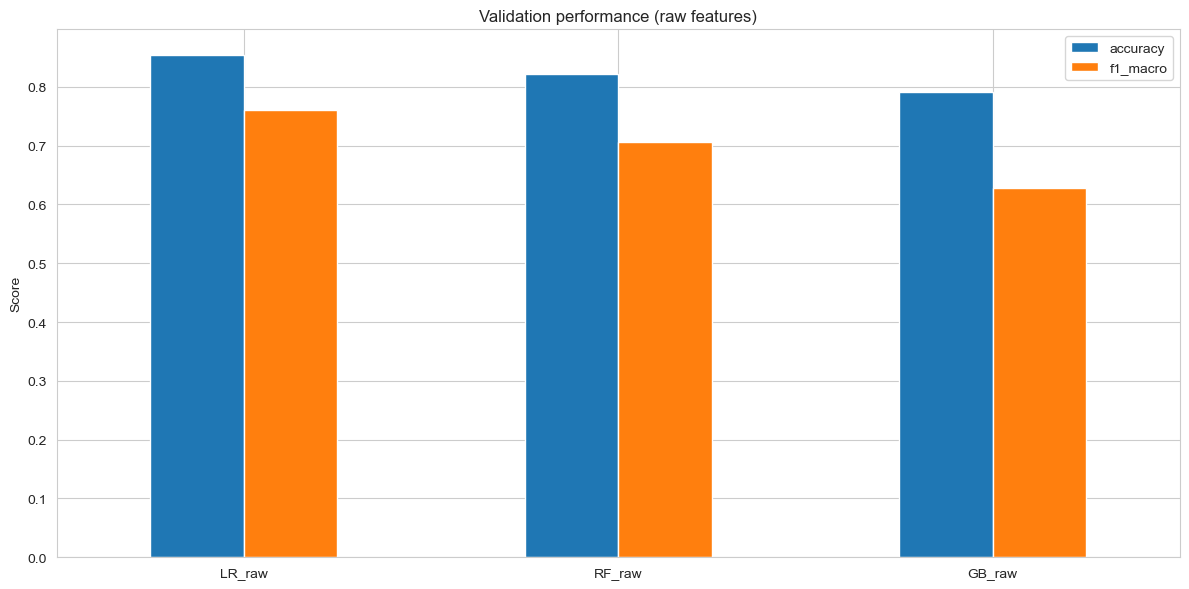

In [24]:
# PSEUDOCODE:
models_val = {
    "LR_raw": lr_val_metrics,
    "RF_raw": rf_val_metrics,
    "GB_raw": gb_val_metrics,
}
#
val_df = pd.DataFrame(models_val).T
print("\nValidation performance:")
print(val_df)
#
ax = val_df[["accuracy", "f1_macro"]].plot(kind="bar")
ax.set_ylabel("Score")
ax.set_title("Validation performance (raw features)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Student direction:**

- Use this summary to form an initial opinion: which model is best on validation?
- You will later see how they behave on the held‑out test set in the evaluation notebook.

***

## 10. Checklist for this ML training notebook

By the end of `03_ml_training.ipynb`, you should have:

- A clear `X` (features) and `y` (binary center label) defined.
- A reproducible train/val/test split, with `.npy` files saved for the test set.
- Standardized training features (`X_raw_std`) for use in linear/boosting models.
- Three saved models in `results/models/`:
    - `lr_raw_binary_centers.pkl`
    - `rf_raw_binary_centers.pkl`
    - `gb_raw_binary_centers.pkl`
- A small summary of validation performance (accuracy and macro‑F1) and a short written reflection on which model seems most promising and why.
<span style="display:none">[^8_1]</span>

[^8_1]: 03_ml_training.ipynb